In [3]:
pip install scikit-learn

     |████████████████████████████████| 11.1 MB 12.1 MB/s eta 0:00:01
     |████████████████████████████████| 301 kB 39.5 MB/s eta 0:00:01
     |████████████████████████████████| 34.5 MB 76.6 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.ticker as ticker

In [3]:
RUN_ID = "DEFINE AS A CONSTANT HERE"

# Starting the Instance

In [4]:
start_df_not_preinitialized = pd.read_csv('/home/user/storage-stick/log/[2024-06-10 12:59:16.947060]/start_data.csv')
start_df_preintialized = pd.read_csv('/home/user/storage-stick/log/[2024-06-06 15:27:20.978978]/start_data.csv')

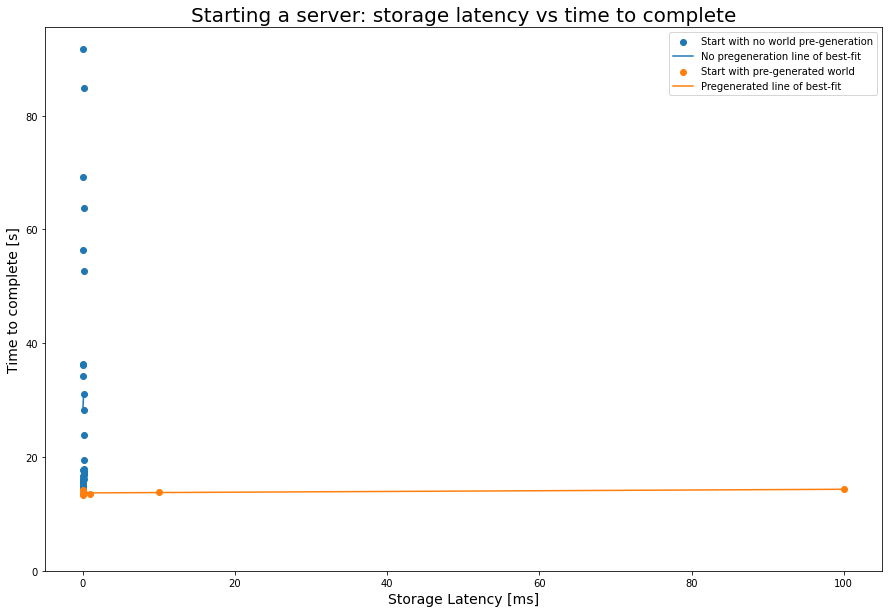

In [5]:
not_pre_x = start_df_not_preinitialized.latency  / 1e6
not_pre_y = start_df_not_preinitialized.time

pre_x = start_df_preintialized.latency / 1e6
pre_y = start_df_preintialized.time

plt.figure(figsize=(15,10))

plt.title('Starting a server: storage latency vs time to complete', fontsize=20)

plt.scatter(not_pre_x, not_pre_y, label='Start with no world pre-generation')
plt.plot(np.unique(not_pre_x), np.poly1d(np.polyfit(not_pre_x, not_pre_y, 1))(np.unique(not_pre_x)), label='No pregeneration line of best-fit')

plt.scatter(pre_x, pre_y, label='Start with pre-generated world')
plt.plot(np.unique(pre_x), np.poly1d(np.polyfit(pre_x, pre_y, 1))(np.unique(pre_x)), label='Pregenerated line of best-fit')

plt.scatter
plt.ylim(ymin=0)  # this line

plt.xlabel('Storage Latency [ms]', fontsize=14)
plt.ylabel('Time to complete [s]', fontsize=14)

plt.legend()
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))

plt.show()

# Terminating the Instance

In [26]:
termination_df_not_preinitialized = pd.read_csv('/home/user/storage-stick/log/[2024-06-06 15:05:14.597765]/termination.csv')
termination_df_preintialized = pd.read_csv('/home/user/storage-stick/log/[2024-06-06 15:27:20.978978]/termination.csv')

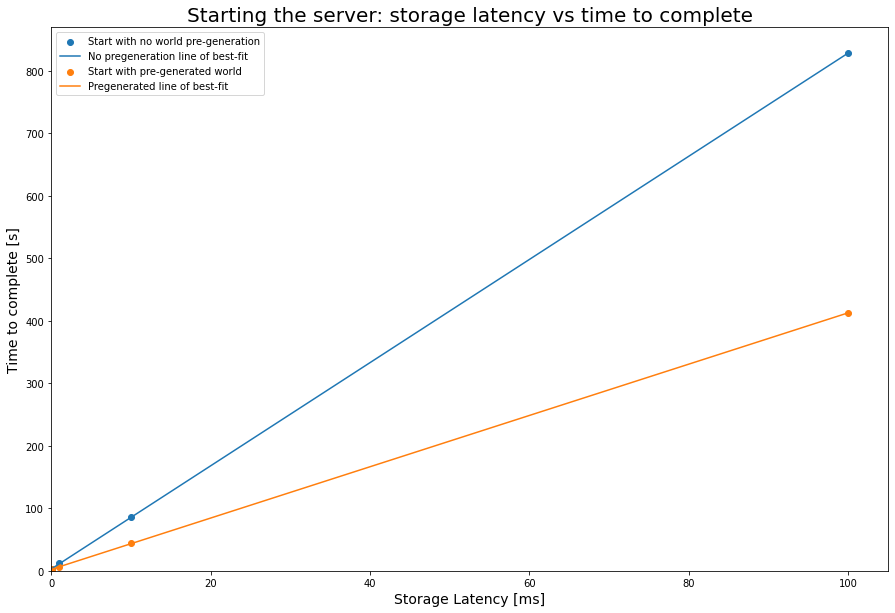

In [30]:
not_pre_x = termination_df_not_preinitialized.latency  / 1e6
not_pre_y = termination_df_not_preinitialized.time

pre_x = termination_df_preintialized.latency / 1e6
pre_y = termination_df_preintialized.time

plt.figure(figsize=(15,10))

plt.title('Terminating a server: storage latency vs time to complete', fontsize=20)

plt.scatter(not_pre_x, not_pre_y, label='Start with no world pre-generation')
plt.plot(np.unique(not_pre_x), np.poly1d(np.polyfit(not_pre_x, not_pre_y, 1))(np.unique(not_pre_x)), label='No pregeneration line of best-fit')

plt.scatter(pre_x, pre_y, label='Start with pre-generated world')
plt.plot(np.unique(pre_x), np.poly1d(np.polyfit(pre_x, pre_y, 1))(np.unique(pre_x)), label='Pregenerated line of best-fit')

plt.scatter
plt.ylim(ymin=0)  # this line
plt.xlim(xmin=0)

plt.xlabel('Storage Latency [ms]', fontsize=14)
plt.ylabel('Time to complete [s]', fontsize=14)

plt.legend()
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))

plt.show()

# Analysis with Memory and Stuff

In [60]:
start_df_not_preinitialized = pd.read_csv('/home/user/storage-stick/log/[2024-06-10 12:59:16.947060]/start_data.csv')
terminate_df_not_preinitialized = pd.read_csv('/home/user/storage-stick/log/[2024-06-10 12:59:16.947060]/termination.csv')

In [61]:
terminate_df_not_preinitialized

,Unnamed: 0,latency,mem_limit,mems_limit,sample_num,time
0,0,10000,1024,2048,0,19.572920
1,1,10000,1024,2048,1,22.024884
2,2,10000,1024,2048,2,12.974550
3,3,10000,1024,4096,0,90.740358
4,4,10000,1024,4096,1,61.424132
5,5,10000,1024,4096,2,58.375755
6,6,10000,2048,2048,0,2.330461
7,7,10000,2048,2048,1,4.377704
8,8,10000,2048,2048,2,2.986821
9,9,10000,2048,4096,0,2.399791


In [62]:
mem_limits = start_df_not_preinitialized['mem_limit'].unique()
mems_limits = start_df_not_preinitialized['mems_limit'].unique()
latencies = start_df_not_preinitialized['latency'].unique()

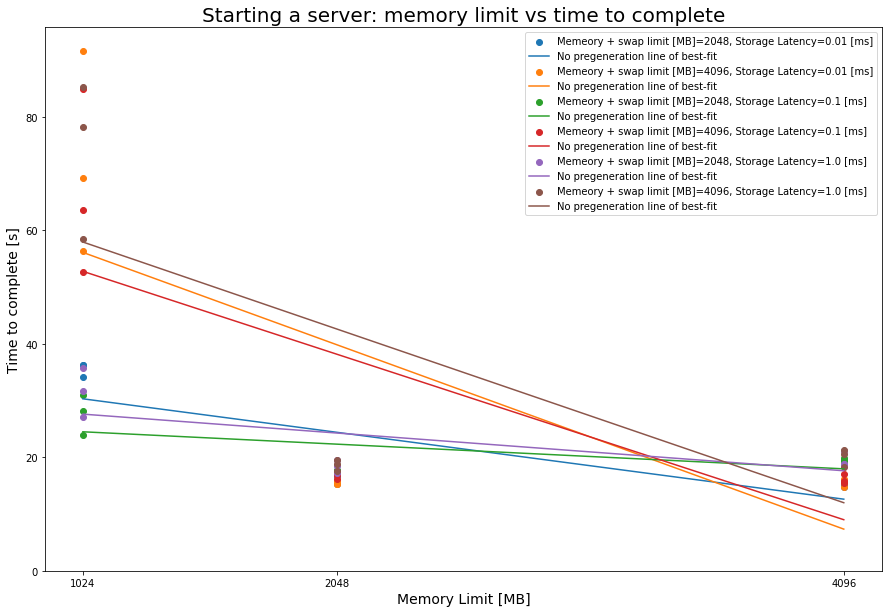

In [63]:
plt.figure(figsize=(15,10))
plt.title('Starting a server: memory limit vs time to complete', fontsize=20)

for latency in latencies:
    for mems_limit in mems_limits:
        data_to_plot = start_df_not_preinitialized[(start_df_not_preinitialized['mems_limit'] == mems_limit) & 
                                                   (start_df_not_preinitialized['latency'] == latency)]
        
        x = data_to_plot['mem_limit']
        y = data_to_plot['time']
        
        plt.scatter(x, y, label=f'Memeory + swap limit [MB]={mems_limit}, Storage Latency={latency  / 1e6} [ms]')
        plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)), label='No pregeneration line of best-fit')


plt.legend()
plt.ylim(ymin=0)

plt.xlabel('Memory Limit [MB]', fontsize=14)
plt.ylabel('Time to complete [s]', fontsize=14)

plt.xticks([1024, 2048, 4096])
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))

plt.show()


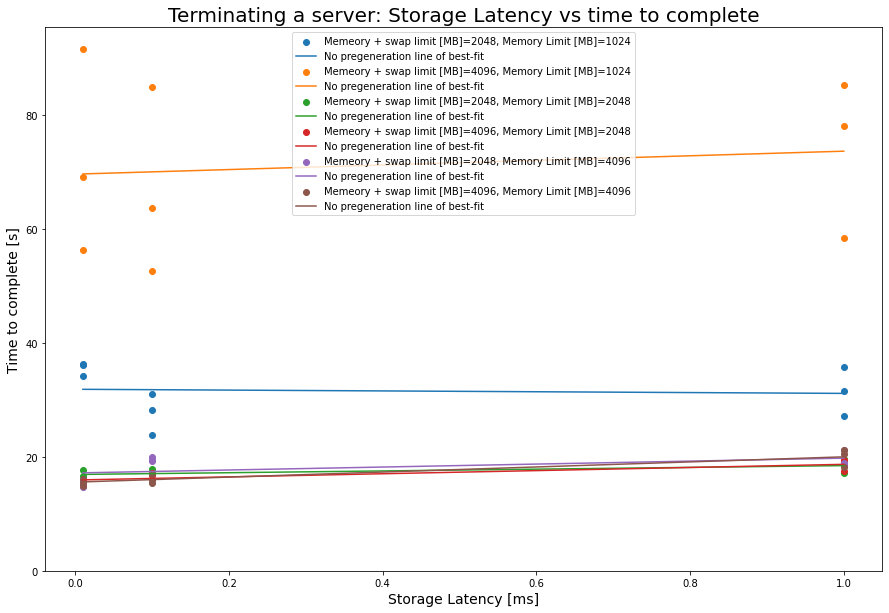

In [57]:
plt.figure(figsize=(15,10))
plt.title('Terminating a server: Storage Latency vs time to complete', fontsize=20)

for mem_limit in mem_limits:
    for mems_limit in mems_limits:
        data_to_plot = start_df_not_preinitialized[(start_df_not_preinitialized['mems_limit'] == mems_limit) & 
                                                   (start_df_not_preinitialized['mem_limit'] == mem_limit)]
        
        x = data_to_plot['latency'] / 1e6
        y = data_to_plot['time']
        
        plt.scatter(x, y, label=f'Memeory + swap limit [MB]={mems_limit}, Memory Limit [MB]={mem_limit}')
        plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)), label='No pregeneration line of best-fit')


plt.legend()
plt.ylim(ymin=0)

plt.xlabel('Storage Latency [ms]', fontsize=14)
plt.ylabel('Time to complete [s]', fontsize=14)

plt.show()